In [7]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 48.7 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [10]:
# =========================
# Patch ConvLSTM Fire Classification Trainer
# Key guarantees
# 1) -9999 and nodata never enter the model inputs
# 2) robust raster reads using masked=True, boundless=True, fill_value=0
# 3) optional missingness mask channel so model can distinguish real zeros vs filled zeros
# 4) sanity checks report valid ranges and nodata rates, not raw min=-9999 artifacts
# =========================

import os
import json
import time
import math
import random
import traceback
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import pandas as pd
import rasterio
from rasterio.windows import Window


# =========================
# CONFIG
# =========================
DATASET_DIR = "/kaggle/input/prometheus"

DATA_ROOT = f"{DATASET_DIR}/data_processed_normalized"
FIRE_ROOT = f"{DATASET_DIR}/fire16"

TRAIN_CSV = f"{DATASET_DIR}/dataset/dataset_index_train_vr50.csv"
VAL_CSV   = f"{DATASET_DIR}/dataset/dataset_index_val.csv"
TEST_CSV  = f"{DATASET_DIR}/dataset/dataset_index_test.csv"

VARS = ["ndvi16", "temp16", "precip16", "rh16", "vpd16", "elevation", "slope"]

PATCH_SIZE = 32
BATCH_SIZE = 64

INPUT_STEPS = 3              # uses t1..t{INPUT_STEPS}
MAX_EPOCHS = 20
LR = 2e-4
WEIGHT_DECAY = 1e-4

# Patch level label from CSV, column name must exist
PATCH_LABEL_COL = "has_fire"  # 0 or 1 per patch row

# Handling missingness
FILL_VALUE = 0.0
ADD_MISSINGNESS_MASK = True   # adds 1 extra channel per time step
MASK_VALUE_WHEN_VALID = 1.0
MASK_VALUE_WHEN_MISSING = 0.0

# Sampling and imbalance
USE_WEIGHTED_SAMPLER = True
SAMPLER_POS_MULTIPLIER = 1.0  # 1.0 means inverse counts, reduce below 1.0 to soften oversampling

# Loss
USE_FOCAL = True
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0
BCE_POS_WEIGHT_CLIP = 50.0

# Threshold selection
THR_SWEEP = [round(x, 2) for x in np.arange(0.10, 0.91, 0.05)]

# Performance knobs for Kaggle
NUM_WORKERS = 2
PREFETCH_FACTOR = 2
PERSISTENT_WORKERS = True
PIN_MEMORY = True
RASTER_CACHE_LIMIT = 16
USE_AMP = True
GRAD_CLIP_NORM = 1.0

# Early stopping
EARLYSTOP_PATIENCE = 5
EARLYSTOP_MIN_DELTA = 1e-4

# tqdm rendering
TQDM_LEAVE = True

# =========================
# RUN OUTPUT DIR
# =========================
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path(f"/kaggle/working/runs/patch_convlstm_{RUN_ID}")
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_BEST = RUN_DIR / "best.pt"
CKPT_LAST = RUN_DIR / "last.pt"
LOG_CSV   = RUN_DIR / "train_log.csv"
CFG_JSON  = RUN_DIR / "config.json"
ERR_LOG   = RUN_DIR / "errors.log"


# =========================
# PERFORMANCE
# =========================
try:
    torch.set_num_threads(4)
except Exception:
    pass

try:
    torch.backends.cudnn.benchmark = True
except Exception:
    pass


# =========================
# UTIL
# =========================
def save_json(path: Path, obj: dict):
    path.write_text(json.dumps(obj, indent=2))

def now_s():
    return time.time()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def sigmoid_np(x: torch.Tensor):
    return torch.sigmoid(x).detach().cpu().numpy()

def safe_nanmean(x):
    x = np.asarray(x, dtype=np.float64)
    if np.all(np.isnan(x)):
        return float("nan")
    return float(np.nanmean(x))


# =========================
# METRICS
# =========================
@torch.no_grad()
def pr_curve_metrics_from_logits(logits, targets, thresholds):
    """
    logits: (B,1) or (B,)
    targets: (B,) float 0/1
    returns list of dicts with thr, P, R, F1
    """
    if logits.ndim == 2 and logits.shape[1] == 1:
        logits = logits[:, 0]
    probs = torch.sigmoid(logits).float()
    y = targets.float()

    rows = []
    eps = 1e-9
    for thr in thresholds:
        pred = (probs >= thr).float()
        tp = (pred * y).sum().item()
        fp = (pred * (1 - y)).sum().item()
        fn = ((1 - pred) * y).sum().item()

        p = (tp + eps) / (tp + fp + eps)
        r = (tp + eps) / (tp + fn + eps)
        f1 = (2 * p * r) / (p + r + eps)
        rows.append({"thr": float(thr), "P": float(p), "R": float(r), "F1": float(f1)})
    return rows

@torch.no_grad()
def average_precision_from_probs(probs, y_true):
    """
    Computes PR AUC (Average Precision) without sklearn.
    probs: numpy array shape (N,)
    y_true: numpy array shape (N,) 0/1
    """
    probs = np.asarray(probs, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    order = np.argsort(-probs)
    y = y_true[order]
    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)
    denom = tp + fp
    precision = tp / np.maximum(denom, 1)
    recall = tp / max((y_true == 1).sum(), 1)

    # AP as sum over recall steps
    ap = 0.0
    prev_recall = 0.0
    for p, r in zip(precision, recall):
        ap += p * (r - prev_recall)
        prev_recall = r
    return float(ap)


# =========================
# LOSS
# =========================
class FocalBCEWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none"
        )
        p = torch.sigmoid(logits)
        pt = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()

def make_loss(pos_weight_tensor):
    if USE_FOCAL:
        return FocalBCEWithLogits(
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
            pos_weight=pos_weight_tensor
        )
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


# =========================
# DATASET
# Robust nodata handling:
# 1) masked=True ensures nodata and outside window pixels are masked
# 2) boundless=True ensures patch size is consistent at edges
# 3) fill_value=0 ensures missing pixels are filled with 0
# Optional missingness mask channel:
# 1 means valid, 0 means missing
# =========================
class FirePatchSeqDataset(Dataset):
    def __init__(
        self,
        index_csv,
        data_root,
        fire_root,
        variables,
        patch_size=32,
        input_steps=3,
        label_col="has_fire",
        cache_limit=16,
        add_missingness_mask=True,
        fill_value=0.0,
    ):
        self.data_root = Path(data_root)
        self.fire_root = Path(fire_root)
        self.variables = list(variables)
        self.patch = int(patch_size)
        self.input_steps = int(input_steps)
        self.label_col = str(label_col)
        self.cache_limit = int(cache_limit)

        self.add_missingness_mask = bool(add_missingness_mask)
        self.fill_value = float(fill_value)

        # Read index
        time_cols = [f"t{i}" for i in range(1, self.input_steps + 2)]  # includes t{input_steps+1} which is target time
        dtype_map = {c: "string" for c in time_cols}
        self.df = pd.read_csv(index_csv, dtype=dtype_map)

        # Clean possible ".0" strings
        for c in time_cols:
            if c in self.df.columns:
                self.df[c] = self.df[c].astype("string").str.replace(r"\.0$", "", regex=True)

        # Validate required columns
        must = ["year", "patch_row", "patch_col", self.label_col] + time_cols
        missing = [c for c in must if c not in self.df.columns]
        if missing:
            raise ValueError(f"Index CSV missing columns: {missing}")

        # Per worker cache
        self._src_cache = None
        self._src_order = None

    def __len__(self):
        return len(self.df)

    def _ensure_cache(self):
        if self._src_cache is None:
            self._src_cache = {}
            self._src_order = []

    def close(self):
        if self._src_cache is None:
            return
        for _, src in list(self._src_cache.items()):
            try:
                src.close()
            except Exception:
                pass
        self._src_cache.clear()
        self._src_order.clear()

    def _get_src(self, path: Path):
        self._ensure_cache()
        key = str(path)
        src = self._src_cache.get(key)
        if src is not None:
            return src

        src = rasterio.open(path)
        self._src_cache[key] = src
        self._src_order.append(key)

        if len(self._src_order) > self.cache_limit:
            old = self._src_order.pop(0)
            old_src = self._src_cache.pop(old, None)
            if old_src is not None:
                try:
                    old_src.close()
                except Exception:
                    pass
        return src

    def _read_patch_masked(self, path: Path, r: int, c: int):
        """
        Returns
        arr_filled float32 shape (H,W) with missing filled as self.fill_value
        valid_mask float32 shape (H,W) 1 where valid, 0 where missing
        """
        path = Path(path)
        if not path.exists():
            # treat missing file as all missing
            arr = np.full((self.patch, self.patch), self.fill_value, dtype=np.float32)
            m = np.zeros((self.patch, self.patch), dtype=np.float32)
            return arr, m

        src = self._get_src(path)
        window = Window(col_off=int(c), row_off=int(r), width=self.patch, height=self.patch)

        # masked=True makes nodata masked
        # boundless=True ensures consistent shape at edges
        # fill_value used for out of bounds when boundless
        ma = src.read(
            1,
            window=window,
            masked=True,
            boundless=True,
            fill_value=self.fill_value
        )

        # ma is masked array, missing where mask True
        # valid if not masked
        if np.ma.isMaskedArray(ma):
            valid = (~ma.mask).astype(np.float32)
            arr = ma.filled(self.fill_value).astype(np.float32)
        else:
            # If rasterio returned ndarray (rare), rely on src.nodata if present
            arr = ma.astype(np.float32)
            nodata = src.nodata
            if nodata is None:
                valid = np.ones_like(arr, dtype=np.float32)
            else:
                # float nodata can be imprecise, use isclose
                is_missing = np.isclose(arr, float(nodata))
                valid = (~is_missing).astype(np.float32)
                arr = np.where(is_missing, self.fill_value, arr).astype(np.float32)

        # Final safety, remove any stray -9999 without relying on equality
        # If your pipeline wrote -9999 but metadata nodata was lost, this prevents leakage.
        arr = np.where(arr < -1e3, self.fill_value, arr).astype(np.float32)
        valid = np.where(arr < -1e3, 0.0, valid).astype(np.float32)

        return arr, valid

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        year = int(row["year"])
        r = int(row["patch_row"])
        c = int(row["patch_col"])

        # Times for input frames, t1..t{input_steps}
        t_in = [str(row[f"t{i}"]) for i in range(1, self.input_steps + 1)]

        frames = []
        for t in t_in:
            channels = []
            masks = []

            for var in self.variables:
                if var in ["elevation", "slope"]:
                    path = self.data_root / "static" / f"{var}_static_srtm.tif"
                else:
                    path = self.data_root / var / str(year) / f"{var}_{year}_{t}.tif"

                arr, valid = self._read_patch_masked(path, r, c)
                channels.append(arr)
                masks.append(valid)

            x = np.stack(channels, axis=0)  # (C,H,W)
            if self.add_missingness_mask:
                # Combine masks into a single mask channel
                # valid across all variables at that pixel
                m = np.stack(masks, axis=0)                  # (C,H,W)
                m_all = (m.min(axis=0) > 0.5).astype(np.float32)  # (H,W)
                x = np.concatenate([x, m_all[None, ...]], axis=0)  # (C+1,H,W)

            frames.append(x)

        X_np = np.stack(frames, axis=0).astype(np.float32)  # (T,C,H,W)

        # Patch label
        y = float(row[self.label_col])
        y = 1.0 if y > 0 else 0.0

        X = torch.from_numpy(X_np)               # (T,C,H,W)
        y = torch.tensor(y, dtype=torch.float32) # scalar

        return X, y


# =========================
# MODEL
# Encoder per frame, ConvLSTM, patch head
# Output logits (B,1)
# =========================
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_channels = int(hidden_channels)
        self.conv = nn.Conv2d(
            in_channels=int(input_channels) + int(hidden_channels),
            out_channels=4 * int(hidden_channels),
            kernel_size=int(kernel_size),
            padding=int(padding)
        )

    def forward(self, x, state):
        h, c = state
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_state(self, batch, spatial, device, dtype):
        H, W = spatial
        h = torch.zeros(batch, self.hidden_channels, H, W, device=device, dtype=dtype)
        c = torch.zeros(batch, self.hidden_channels, H, W, device=device, dtype=dtype)
        return h, c


class ConvLSTM(nn.Module):
    def __init__(self, input_channels, hidden_channels, num_layers=1, kernel_size=3):
        super().__init__()
        self.num_layers = int(num_layers)

        if isinstance(hidden_channels, (list, tuple)):
            hidden_list = list(hidden_channels)
        else:
            hidden_list = [int(hidden_channels)] * self.num_layers
        assert len(hidden_list) == self.num_layers

        cells = []
        for i in range(self.num_layers):
            in_ch = int(input_channels) if i == 0 else int(hidden_list[i - 1])
            cells.append(ConvLSTMCell(in_ch, int(hidden_list[i]), kernel_size=kernel_size))
        self.cells = nn.ModuleList(cells)

    def forward(self, x):
        # x: (B,T,C,H,W)
        B, T, C, H, W = x.shape
        device = x.device
        dtype = x.dtype

        layer_input = x
        for cell in self.cells:
            h, c = cell.init_state(B, (H, W), device, dtype)
            outputs = []
            for t in range(T):
                h, c = cell(layer_input[:, t], (h, c))
                outputs.append(h)
            layer_input = torch.stack(outputs, dim=1)  # (B,T,Hc,H,W)

        return layer_input  # last layer sequence


class FirePatchConvLSTM(nn.Module):
    def __init__(self, in_channels, hidden=64, lstm_layers=1, kernel=3, dropout=0.2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.convlstm = ConvLSTM(
            input_channels=32,
            hidden_channels=[hidden] * int(lstm_layers),
            num_layers=int(lstm_layers),
            kernel_size=int(kernel)
        )

        self.drop = nn.Dropout(float(dropout))

        # Patch head
        self.head = nn.Sequential(
            nn.Conv2d(hidden, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # x: (B,T,C,H,W)
        B, T, C, H, W = x.shape

        x2 = x.reshape(B * T, C, H, W)
        f2 = self.encoder(x2)                  # (B*T,32,H,W)
        feats = f2.reshape(B, T, 32, H, W)     # (B,T,32,H,W)

        seq = self.convlstm(feats)             # (B,T,hidden,H,W)
        h_last = seq[:, -1]                    # (B,hidden,H,W)

        h_last = self.drop(h_last)
        pooled = self.head(h_last).reshape(B, 64)
        logits = self.fc(pooled)               # (B,1)
        return logits


# =========================
# LOADERS
# =========================
def make_loader(csv_path, train: bool):
    ds = FirePatchSeqDataset(
        index_csv=csv_path,
        data_root=DATA_ROOT,
        fire_root=FIRE_ROOT,
        variables=VARS,
        patch_size=PATCH_SIZE,
        input_steps=INPUT_STEPS,
        label_col=PATCH_LABEL_COL,
        cache_limit=RASTER_CACHE_LIMIT,
        add_missingness_mask=ADD_MISSINGNESS_MASK,
        fill_value=FILL_VALUE,
    )

    dl_kwargs = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        shuffle=False,
    )
    if NUM_WORKERS > 0 and PERSISTENT_WORKERS:
        dl_kwargs["persistent_workers"] = True
        dl_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    if train and USE_WEIGHTED_SAMPLER:
        y = ds.df[PATCH_LABEL_COL].astype(int).to_numpy()
        counts = np.bincount(y, minlength=2).astype(np.float64)
        # softened inverse frequency if multiplier < 1
        w0 = 1.0 / max(counts[0], 1.0)
        w1 = 1.0 / max(counts[1], 1.0)
        # soften by exponent in [0,1]
        exp = float(SAMPLER_POS_MULTIPLIER)
        w0s = w0 ** exp
        w1s = w1 ** exp
        weights = np.where(y == 1, w1s, w0s).astype(np.float32)
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(weights),
            num_samples=len(weights),
            replacement=True
        )
        dl_kwargs["sampler"] = sampler
    else:
        if train:
            dl_kwargs["shuffle"] = True

    loader = DataLoader(ds, **dl_kwargs)
    return ds, loader


# =========================
# POS_WEIGHT (for BCE focal pos_weight)
# =========================
def compute_patch_pos_weight(train_ds):
    y = train_ds.df[PATCH_LABEL_COL].astype(int).to_numpy()
    pos = float((y == 1).sum())
    neg = float((y == 0).sum())
    if pos < 1:
        return 1.0
    raw = neg / pos
    return float(np.clip(raw, 1.0, BCE_POS_WEIGHT_CLIP))


# =========================
# SANITY SCAN
# Checks per channel:
# valid_min, valid_max, missing_rate
# If ADD_MISSINGNESS_MASK=True, the last channel is the combined valid mask
# =========================
@torch.no_grad()
def sanity_scan(loader, max_batches=4):
    mins = None
    maxs = None
    miss = None
    total = 0

    for bi, (X, y) in enumerate(loader):
        # X: (B,T,C,H,W)
        X = X.numpy()
        B, T, C, H, W = X.shape

        # If mask channel exists, treat it as validness indicator
        if ADD_MISSINGNESS_MASK:
            mask = X[:, :, -1, :, :]  # (B,T,H,W), 1 valid, 0 missing
            feat = X[:, :, :-1, :, :]
        else:
            mask = None
            feat = X

        # Flatten over batch and time
        feat = feat.reshape(B * T, feat.shape[2], H, W)

        if mask is None:
            valid = np.ones((B * T, H, W), dtype=np.float32)
        else:
            valid = mask.reshape(B * T, H, W)

        # Per channel stats only on valid pixels
        c_mins = []
        c_maxs = []
        c_miss = []
        for ci in range(feat.shape[1]):
            arr = feat[:, ci, :, :]
            v = valid > 0.5

            if v.any():
                c_mins.append(float(arr[v].min()))
                c_maxs.append(float(arr[v].max()))
            else:
                c_mins.append(float("nan"))
                c_maxs.append(float("nan"))

            c_miss.append(float(1.0 - v.mean()))

        if mins is None:
            mins = np.array(c_mins, dtype=np.float64)
            maxs = np.array(c_maxs, dtype=np.float64)
            miss = np.array(c_miss, dtype=np.float64)
        else:
            mins = np.nanmin(np.stack([mins, c_mins], axis=0), axis=0)
            maxs = np.nanmax(np.stack([maxs, c_maxs], axis=0), axis=0)
            miss = (miss * total + np.array(c_miss) * (B * T)) / (total + B * T)

        total += B * T
        if bi + 1 >= max_batches:
            break

    return {
        "valid_min_per_channel": mins.tolist() if mins is not None else [],
        "valid_max_per_channel": maxs.tolist() if maxs is not None else [],
        "missing_rate_per_channel": miss.tolist() if miss is not None else [],
    }


# =========================
# TRAIN AND EVAL
# =========================
def run_epoch(model, loader, optimizer, criterion, device, train=True, use_amp=True, scaler=None):
    model.train() if train else model.eval()

    total_loss = 0.0
    n = 0

    all_logits = []
    all_y = []

    pbar = tqdm(loader, desc=("Train" if train else "Val"), leave=TQDM_LEAVE)

    for X, y in pbar:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).view(-1, 1)  # (B,1)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=bool(use_amp and device.type == "cuda")):
            logits = model(X)
            loss = criterion(logits, y)

        if train:
            if use_amp and device.type == "cuda":
                scaler.scale(loss).backward()
                if GRAD_CLIP_NORM is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if GRAD_CLIP_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

        total_loss += float(loss.item()) * y.shape[0]
        n += y.shape[0]

        all_logits.append(logits.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

        pbar.set_postfix({"loss": f"{(total_loss / max(n,1)):.4f}"})

    logits_all = torch.cat(all_logits, dim=0) if all_logits else torch.empty((0, 1))
    y_all = torch.cat(all_y, dim=0) if all_y else torch.empty((0, 1))

    probs = torch.sigmoid(logits_all).numpy().reshape(-1)
    y_np = y_all.numpy().reshape(-1)

    pr_auc = average_precision_from_probs(probs, y_np)

    return {
        "loss": float(total_loss / max(n, 1)),
        "probs": probs,
        "y": y_np,
        "pr_auc": float(pr_auc),
    }


def pick_best_threshold_from_probs(probs, y_true, thresholds):
    probs_t = torch.tensor(probs, dtype=torch.float32)
    y_t = torch.tensor(y_true, dtype=torch.float32)
    rows = pr_curve_metrics_from_logits(torch.logit(probs_t.clamp(1e-6, 1-1e-6)), y_t, thresholds)
    best = max(rows, key=lambda r: r["F1"])
    return rows, float(best["thr"]), best


class EarlyStopper:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = float("inf")
        self.bad = 0

    def step(self, val_loss):
        improved = (val_loss < self.best - self.min_delta)
        if improved:
            self.best = val_loss
            self.bad = 0
        else:
            self.bad += 1
        return improved, (self.bad >= self.patience)


# =========================
# MAIN
# =========================
def main():
    set_seed(42)

    config = {
        "DATASET_DIR": DATASET_DIR,
        "DATA_ROOT": DATA_ROOT,
        "FIRE_ROOT": FIRE_ROOT,
        "TRAIN_CSV": TRAIN_CSV,
        "VAL_CSV": VAL_CSV,
        "TEST_CSV": TEST_CSV,
        "VARS": VARS,
        "PATCH_SIZE": PATCH_SIZE,
        "BATCH_SIZE": BATCH_SIZE,
        "INPUT_STEPS": INPUT_STEPS,
        "ADD_MISSINGNESS_MASK": ADD_MISSINGNESS_MASK,
        "FILL_VALUE": FILL_VALUE,
        "USE_WEIGHTED_SAMPLER": USE_WEIGHTED_SAMPLER,
        "SAMPLER_POS_MULTIPLIER": SAMPLER_POS_MULTIPLIER,
        "USE_FOCAL": USE_FOCAL,
        "FOCAL_ALPHA": FOCAL_ALPHA,
        "FOCAL_GAMMA": FOCAL_GAMMA,
        "BCE_POS_WEIGHT_CLIP": BCE_POS_WEIGHT_CLIP,
        "NUM_WORKERS": NUM_WORKERS,
        "PREFETCH_FACTOR": PREFETCH_FACTOR,
        "PERSISTENT_WORKERS": PERSISTENT_WORKERS,
        "RASTER_CACHE_LIMIT": RASTER_CACHE_LIMIT,
        "LR": LR,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "MAX_EPOCHS": MAX_EPOCHS,
        "EARLYSTOP_PATIENCE": EARLYSTOP_PATIENCE,
        "EARLYSTOP_MIN_DELTA": EARLYSTOP_MIN_DELTA,
        "THR_SWEEP": THR_SWEEP,
        "RUN_DIR": str(RUN_DIR),
    }
    save_json(CFG_JSON, config)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    print("Run dir:", RUN_DIR)

    train_ds, train_loader = make_loader(TRAIN_CSV, train=True)
    val_ds, val_loader = make_loader(VAL_CSV, train=False)
    test_ds, test_loader = make_loader(TEST_CSV, train=False)

    train_counts = [
        float((train_ds.df[PATCH_LABEL_COL].astype(int).to_numpy() == 0).sum()),
        float((train_ds.df[PATCH_LABEL_COL].astype(int).to_numpy() == 1).sum())
    ]
    print("Train patch counts [0,1]:", train_counts)
    print("Train size:", len(train_ds), "Val size:", len(val_ds), "Test size:", len(test_ds))

    # Sanity scan, valid stats only
    scan = sanity_scan(train_loader, max_batches=3)
    print("Sanity valid min per channel:", scan["valid_min_per_channel"])
    print("Sanity valid max per channel:", scan["valid_max_per_channel"])
    print("Sanity missing rate per channel:", scan["missing_rate_per_channel"])

    # Determine input channel count
    base_c = len(VARS)
    in_channels = base_c + (1 if ADD_MISSINGNESS_MASK else 0)

    model = FirePatchConvLSTM(
        in_channels=in_channels,
        hidden=64,
        lstm_layers=1,
        kernel=3,
        dropout=0.2
    ).to(device)

    pos_weight = compute_patch_pos_weight(train_ds)
    pos_weight_tensor = torch.tensor([pos_weight], device=device, dtype=torch.float32)
    criterion = make_loss(pos_weight_tensor)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    scaler = torch.amp.GradScaler("cuda", enabled=bool(USE_AMP and device.type == "cuda"))

    pd.DataFrame(columns=[
        "epoch", "lr",
        "train_loss", "val_loss",
        "val_pr_auc", "val_f1", "val_p", "val_r", "val_thr",
        "time_sec"
    ]).to_csv(LOG_CSV, index=False)

    best_val_loss = float("inf")
    best_payload = None
    early = EarlyStopper(patience=EARLYSTOP_PATIENCE, min_delta=EARLYSTOP_MIN_DELTA)

    log_rows = []

    for epoch in range(1, MAX_EPOCHS + 1):
        t0 = now_s()

        tr = run_epoch(model, train_loader, optimizer, criterion, device, train=True, use_amp=USE_AMP, scaler=scaler)
        va = run_epoch(model, val_loader, optimizer=None, criterion=criterion, device=device, train=False, use_amp=False, scaler=None)

        # Threshold sweep computed from the same probabilities that came from THIS epoch
        thr_rows, best_thr, best_row = pick_best_threshold_from_probs(va["probs"], va["y"], THR_SWEEP)
        val_f1 = best_row["F1"]
        val_p = best_row["P"]
        val_r = best_row["R"]

        dt = now_s() - t0
        lr_now = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "lr": lr_now,
            "train_loss": tr["loss"],
            "val_loss": va["loss"],
            "val_pr_auc": va["pr_auc"],
            "val_f1": val_f1,
            "val_p": val_p,
            "val_r": val_r,
            "val_thr": best_thr,
            "time_sec": dt
        }
        log_rows.append(row)
        pd.DataFrame(log_rows).to_csv(LOG_CSV, index=False)

        print(
            f"Epoch {epoch:02d} lr {lr_now:.2e} "
            f"train_loss {tr['loss']:.4f} val_loss {va['loss']:.4f} "
            f"PR_AUC {va['pr_auc']:.3f} F1 {val_f1:.3f} P {val_p:.3f} R {val_r:.3f} thr {best_thr:.2f} "
            f"time {dt:.1f}s"
        )

        # Always save last
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scaler_state": scaler.state_dict() if scaler is not None else None,
                "pos_weight": float(pos_weight),
                "config": config,
                "val_best_thr": float(best_thr),
                "val_thr_sweep": thr_rows,
                "val_pr_auc": float(va["pr_auc"]),
                "val_f1_at_best_thr": float(val_f1),
            },
            CKPT_LAST
        )

        # Best checkpoint by val loss, keeps threshold sweep matching the checkpoint
        if va["loss"] < best_val_loss:
            best_val_loss = va["loss"]
            best_payload = {
                "epoch": epoch,
                "val_loss": float(va["loss"]),
                "val_pr_auc": float(va["pr_auc"]),
                "val_best_thr": float(best_thr),
                "val_thr_sweep": thr_rows,
                "val_f1": float(val_f1),
                "val_p": float(val_p),
                "val_r": float(val_r),
            }
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scaler_state": scaler.state_dict() if scaler is not None else None,
                    "pos_weight": float(pos_weight),
                    "config": config,
                    "best_payload": best_payload,
                },
                CKPT_BEST
            )
            print("Saved best:", str(CKPT_BEST))

        scheduler.step(va["loss"])
        _, stop = early.step(va["loss"])
        if stop:
            print(f"Early stopping at epoch {epoch}, best val_loss {best_val_loss:.6f}")
            break

    # Evaluate test using best checkpoint and its stored best threshold
    ckpt = torch.load(CKPT_BEST, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    best_thr = float(ckpt.get("best_payload", {}).get("val_best_thr", 0.5))

    te = run_epoch(model, test_loader, optimizer=None, criterion=criterion, device=device, train=False, use_amp=False, scaler=None)
    thr_rows_test, _, best_row_test = pick_best_threshold_from_probs(te["probs"], te["y"], [best_thr])

    test_f1 = best_row_test["F1"]
    test_p = best_row_test["P"]
    test_r = best_row_test["R"]

    summary = {
        "best_checkpoint": str(CKPT_BEST),
        "best_epoch": int(ckpt["epoch"]),
        "best_payload": ckpt.get("best_payload", {}),
        "test_at_val_best_thr": {
            "thr": float(best_thr),
            "loss": float(te["loss"]),
            "pr_auc": float(te["pr_auc"]),
            "f1": float(test_f1),
            "precision": float(test_p),
            "recall": float(test_r),
        }
    }
    save_json(RUN_DIR / "summary.json", summary)
    print("Saved summary:", str(RUN_DIR / "summary.json"))

    # Cleanup raster caches
    try:
        train_loader.dataset.close()
        val_loader.dataset.close()
        test_loader.dataset.close()
    except Exception:
        pass

    # Archive run folder
    tar_path = Path("/kaggle/working") / f"{RUN_DIR.name}.tar.gz"
    os.system(f"tar -czf {tar_path} -C {RUN_DIR.parent} {RUN_DIR.name}")
    print("Saved run archive:", str(tar_path))


if __name__ == "__main__":
    try:
        main()
    except Exception:
        tb = traceback.format_exc()
        ERR_LOG.write_text(tb)
        print("Run failed, traceback saved to:", str(ERR_LOG))
        raise


Device: cpu
Run dir: /kaggle/working/runs/patch_convlstm_20260112_034037
Train patch counts [0,1]: [14706.0, 6411.0]
Train size: 21117 Val size: 3673 Test size: 3696


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Sanity valid min per channel: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Sanity valid max per channel: [0.9569663405418396, 0.9683207273483276, 0.9686051607131958, 0.9567211866378784, 0.9882304072380066, 0.9152011275291443, 1.0]
Sanity missing rate per channel: [0.001686943901909747, 0.001686943901909747, 0.001686943901909747, 0.001686943901909747, 0.001686943901909747, 0.001686943901909747, 0.001686943901909747]


Train:   0%|          | 0/330 [00:00<?, ?it/s]

KeyboardInterrupt: 

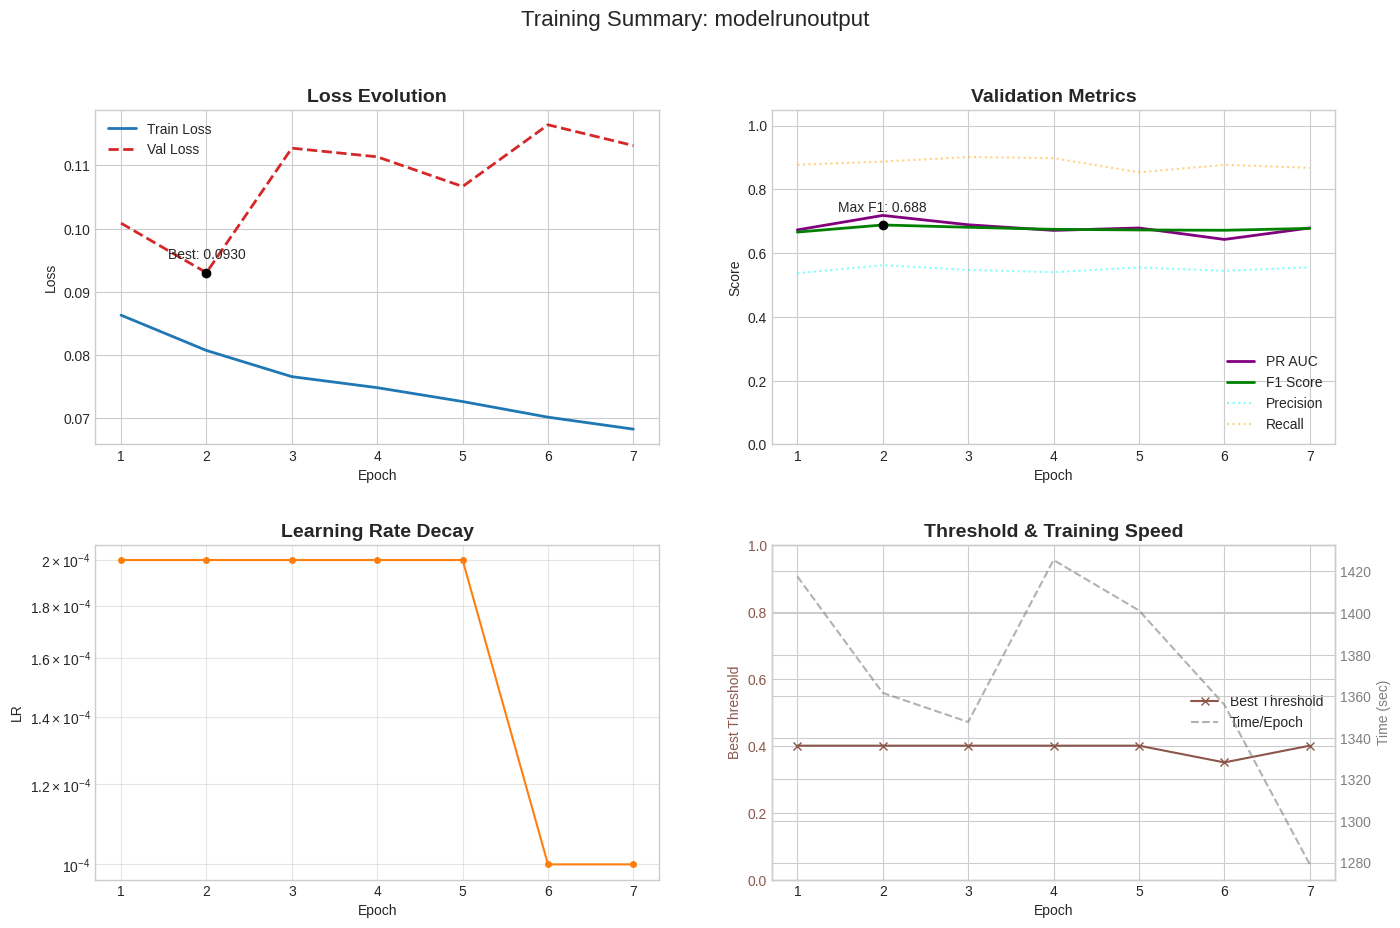

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# CONFIG
# =========================
LOG_CSV_PATH = "/kaggle/input/modelrunoutput/train_log.csv"  # Update this if your path differs

def plot_training_logs(csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: Log file not found at {csv_path}")
        return

    # Read CSV
    df = pd.read_csv(csv_path)
    epochs = df['epoch']

    # Setup Plot Style
    plt.style.use('seaborn-v0_8-whitegrid') # Nice clean style
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.3)

    # -----------------------------
    # 1. Loss Curves (Train vs Val)
    # -----------------------------
    ax1 = axes[0, 0]
    ax1.plot(epochs, df['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
    ax1.plot(epochs, df['val_loss'], label='Val Loss', color='tab:red', linewidth=2, linestyle='--')
    
    # Highlight best val loss
    min_val_loss = df['val_loss'].min()
    best_epoch_loss = df.loc[df['val_loss'] == min_val_loss, 'epoch'].values[0]
    ax1.scatter(best_epoch_loss, min_val_loss, color='black', zorder=5)
    ax1.annotate(f'Best: {min_val_loss:.4f}', (best_epoch_loss, min_val_loss), 
                 textcoords="offset points", xytext=(0,10), ha='center')

    ax1.set_title('Loss Evolution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # -----------------------------
    # 2. Validation Metrics (F1, AUC, P, R)
    # -----------------------------
    ax2 = axes[0, 1]
    ax2.plot(epochs, df['val_pr_auc'], label='PR AUC', color='purple', linewidth=2)
    ax2.plot(epochs, df['val_f1'], label='F1 Score', color='green', linewidth=2)
    # Optional: Plot P and R lightly in background if it gets too crowded
    ax2.plot(epochs, df['val_p'], label='Precision', color='cyan', alpha=0.5, linestyle=':')
    ax2.plot(epochs, df['val_r'], label='Recall', color='orange', alpha=0.5, linestyle=':')

    # Highlight Max F1
    max_f1 = df['val_f1'].max()
    best_epoch_f1 = df.loc[df['val_f1'] == max_f1, 'epoch'].values[0]
    ax2.scatter(best_epoch_f1, max_f1, color='black', zorder=5)
    ax2.annotate(f'Max F1: {max_f1:.3f}', (best_epoch_f1, max_f1), 
                 textcoords="offset points", xytext=(0,10), ha='center')

    ax2.set_title('Validation Metrics', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='lower right')

    # -----------------------------
    # 3. Learning Rate Schedule
    # -----------------------------
    ax3 = axes[1, 0]
    ax3.plot(epochs, df['lr'], label='Learning Rate', color='tab:orange', marker='o', markersize=4)
    ax3.set_title('Learning Rate Decay', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('LR')
    ax3.set_yscale('log') # Log scale is usually better for LR
    ax3.grid(True, which="both", ls="-", alpha=0.5)

    # -----------------------------
    # 4. Threshold & Time
    # -----------------------------
    ax4 = axes[1, 1]
    color = 'tab:brown'
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Best Threshold', color=color)
    line1 = ax4.plot(epochs, df['val_thr'], color=color, label='Best Threshold', marker='x')
    ax4.tick_params(axis='y', labelcolor=color)
    ax4.set_ylim(0, 1.0)

    # Twin axis for Time per epoch
    ax4_twin = ax4.twinx()  
    color_twin = 'tab:gray'
    ax4_twin.set_ylabel('Time (sec)', color=color_twin)
    line2 = ax4_twin.plot(epochs, df['time_sec'], color=color_twin, label='Time/Epoch', linestyle='--', alpha=0.6)
    ax4_twin.tick_params(axis='y', labelcolor=color_twin)

    # Combined legend
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax4.legend(lns, labs, loc='center right')
    ax4.set_title('Threshold & Training Speed', fontsize=14, fontweight='bold')

    plt.suptitle(f'Training Summary: {os.path.basename(os.path.dirname(csv_path))}', fontsize=16)
    plt.show()

# Run the function
# Update the path below to point to your actual log file!
# Example: "/kaggle/working/runs/patch_convlstm_20250112_041133/train_log.csv"

plot_training_logs(LOG_CSV_PATH)


In [ ]:
!zip -r all_files.zip /kaggle/working

Device: cpu
Loading checkpoint: /kaggle/input/modelrunoutput/best.pt
Using Optimal Threshold: 0.4000
Starting inference on 3696 samples...


/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Inference:   0%|          | 0/58 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predictions saved to: /kaggle/working/inference_predictions.csv

Visualizing top predicted fire patches:


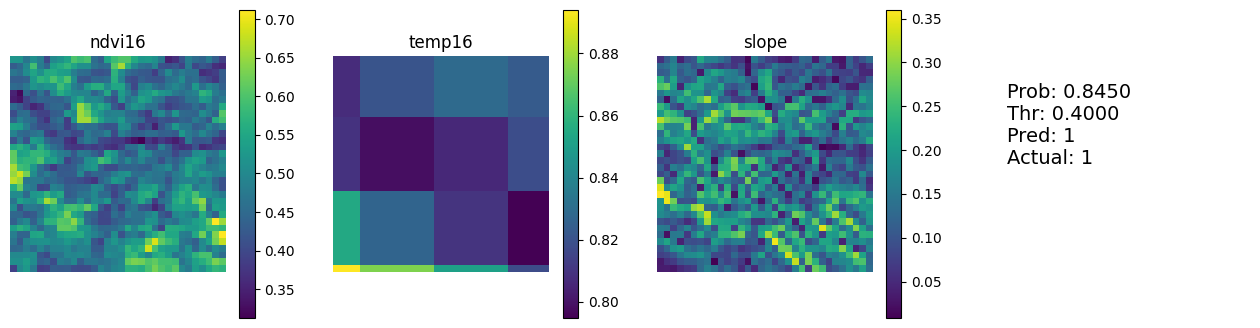

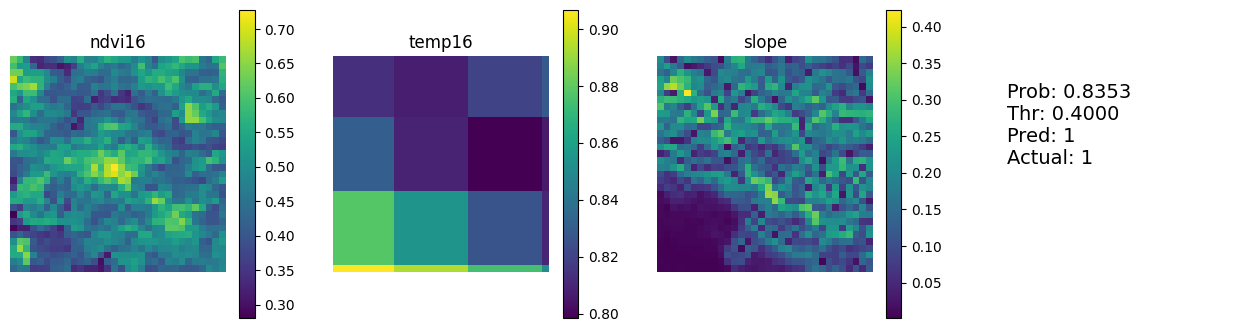

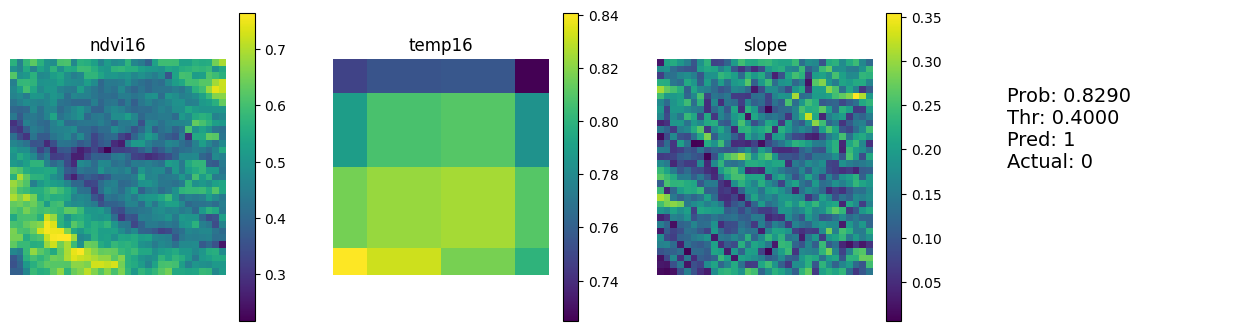

In [11]:
# =========================
# INFERENCE WITH SPECIFIC CHECKPOINT (FIXED)
# =========================
import matplotlib.pyplot as plt
import os
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# Explicit path provided by you
CKPT_PATH = "/kaggle/input/modelrunoutput/best.pt"

def run_specific_inference(ckpt_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found at: {ckpt_path}")

    # 1. Load Checkpoint & Config
    print(f"Loading checkpoint: {ckpt_path}")
    
    # --- FIX: Added weights_only=False to allow loading config dictionaries ---
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    # ------------------------------------------------------------------------
    
    config = checkpoint["config"]
    
    # Extract optimal threshold
    best_thr = 0.5
    if "best_payload" in checkpoint and "val_best_thr" in checkpoint["best_payload"]:
        best_thr = checkpoint["best_payload"]["val_best_thr"]
    elif "val_best_thr" in checkpoint:
        best_thr = checkpoint["val_best_thr"]
    
    print(f"Using Optimal Threshold: {best_thr:.4f}")
    
    # 2. Re-Initialize Model
    # Determine input channels based on config
    base_vars = len(config["VARS"])
    in_channels = base_vars + (1 if config["ADD_MISSINGNESS_MASK"] else 0)
    
    model = FirePatchConvLSTM(
        in_channels=in_channels,
        hidden=64,
        lstm_layers=1,
        kernel=3,
        dropout=0.0
    ).to(device)
    
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    # 3. Setup Test Loader
    test_ds = FirePatchSeqDataset(
        index_csv=config["TEST_CSV"],
        data_root=config["DATA_ROOT"],
        fire_root=config["FIRE_ROOT"],
        variables=config["VARS"],
        patch_size=config["PATCH_SIZE"],
        input_steps=config["INPUT_STEPS"],
        label_col=PATCH_LABEL_COL, 
        add_missingness_mask=config["ADD_MISSINGNESS_MASK"],
        fill_value=config["FILL_VALUE"],
        cache_limit=4
    )
    
    test_loader = DataLoader(
        test_ds, 
        batch_size=config["BATCH_SIZE"], 
        shuffle=False, 
        num_workers=2,
        pin_memory=True
    )
    
    # 4. Run Prediction Loop
    results = []
    print(f"Starting inference on {len(test_ds)} samples...")
    
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", enabled=True):
            for batch_idx, (X, y) in enumerate(tqdm(test_loader, desc="Inference", leave=True)):
                X = X.to(device)
                
                logits = model(X)
                probs = torch.sigmoid(logits).cpu().numpy().flatten()
                
                # Metadata
                start_idx = batch_idx * config["BATCH_SIZE"]
                end_idx = start_idx + len(y)
                
                batch_rows = test_ds.df.iloc[start_idx:end_idx].copy()
                batch_rows["prob_fire"] = probs
                batch_rows["pred_fire"] = (probs >= best_thr).astype(int)
                batch_rows["actual_fire"] = y.numpy().astype(int)
                
                results.append(batch_rows)
                
    # 5. Save CSV
    final_df = pd.concat(results, ignore_index=True)
    
    # Save to working directory
    out_csv = Path("/kaggle/working/inference_predictions.csv")
    final_df.to_csv(out_csv, index=False)
    print(f"Predictions saved to: {out_csv}")
    
    # 6. Visualization
    viz_cols = [v for v in ["ndvi16", "temp16", "slope"] if v in config["VARS"]]
    if not viz_cols:
        viz_cols = config["VARS"][:2]

    # Visualize top 3 highest probability fires
    top_preds = final_df.nlargest(3, "prob_fire")
    print("\nVisualizing top predicted fire patches:")
    
    for idx, row in top_preds.iterrows():
        # Get data directly from dataset (slow but fine for viz)
        X_tensor, y_tensor = test_ds[idx] 
        last_frame = X_tensor[-1].numpy()
        
        fig, axes = plt.subplots(1, len(viz_cols) + 1, figsize=(4 * (len(viz_cols)+1), 4))
        
        for i, v_name in enumerate(viz_cols):
            ch_idx = config["VARS"].index(v_name)
            img = last_frame[ch_idx]
            ax = axes[i]
            im = ax.imshow(img, cmap="viridis")
            ax.set_title(f"{v_name}")
            plt.colorbar(im, ax=ax)
            ax.axis('off')
            
        ax_info = axes[-1]
        ax_info.axis("off")
        info_text = (
            f"Prob: {row['prob_fire']:.4f}\n"
            f"Thr: {best_thr:.4f}\n"
            f"Pred: {int(row['pred_fire'])}\n"
            f"Actual: {int(row['actual_fire'])}"
        )
        ax_info.text(0.1, 0.5, info_text, fontsize=14)
        plt.show()

# Run it
run_specific_inference(CKPT_PATH)

Reading results from: /kaggle/working/inference_predictions.csv

       MODEL PERFORMANCE SUMMARY       
Total Samples    : 3696
Fire Samples     : 1031 (27.9%)
----------------------------------------
Accuracy         : 0.6385
F1 Score         : 0.5809
ROC AUC          : 0.7903
PR AUC (AP)      : 0.5047

Detailed Classification Report:
              precision    recall  f1-score   support

     No Fire       0.93      0.54      0.68      2665
        Fire       0.43      0.90      0.58      1031

    accuracy                           0.64      3696
   macro avg       0.68      0.72      0.63      3696
weighted avg       0.79      0.64      0.65      3696



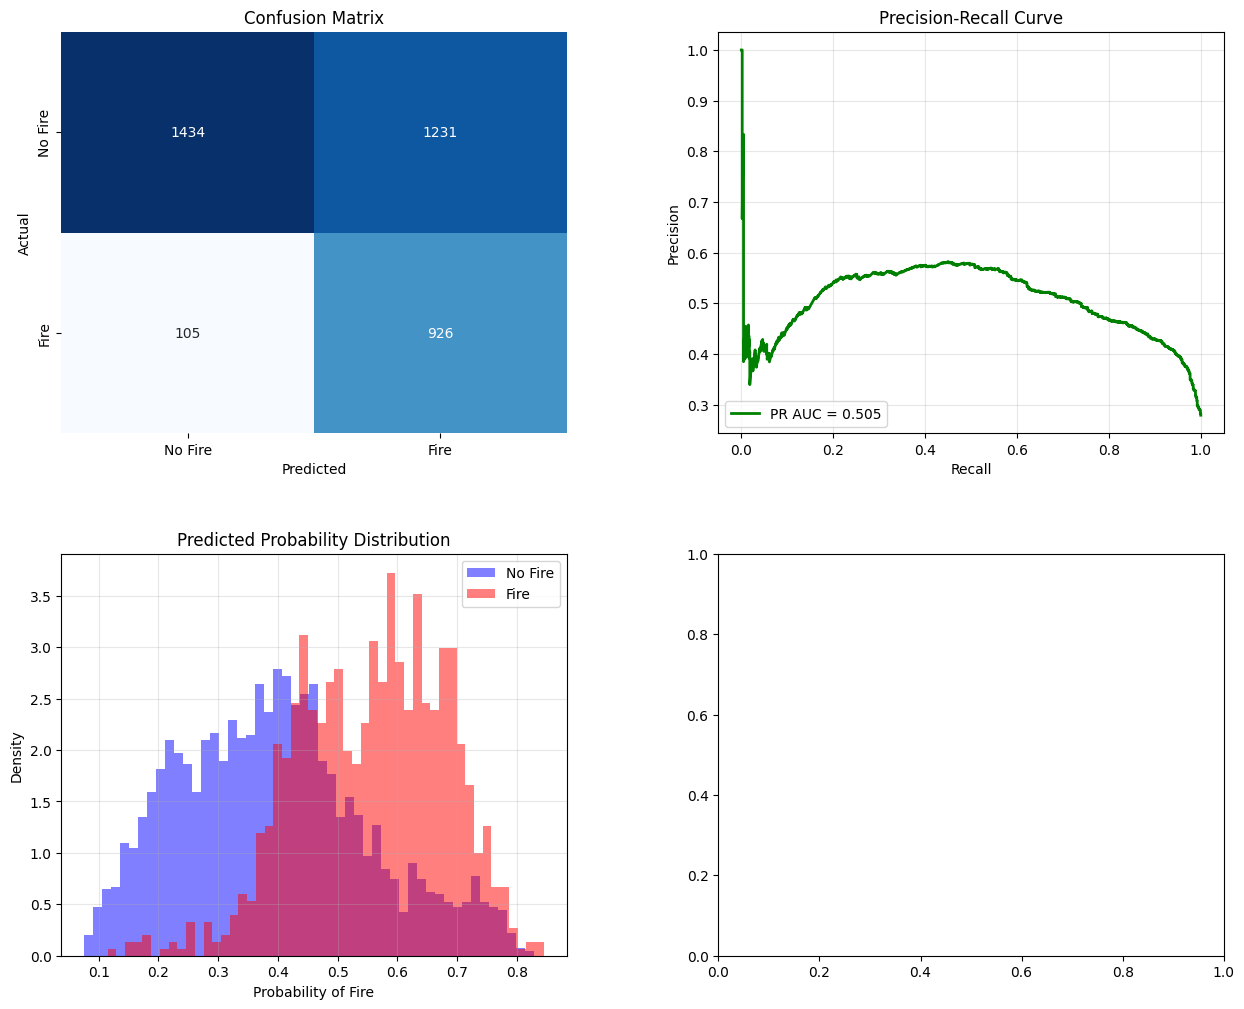

In [14]:
# =========================
# EVALUATION & RESULTS VISUALIZATION
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score,
    average_precision_score, 
    roc_curve, 
    precision_recall_curve, 
    f1_score,
    accuracy_score
)

def evaluate_predictions(csv_path):
    print(f"Reading results from: {csv_path}")
    if not os.path.exists(csv_path):
        print("Error: CSV file not found. Please run the inference code first.")
        return

    df = pd.read_csv(csv_path)
    
    y_true = df["actual_fire"].values
    y_pred = df["pred_fire"].values
    y_prob = df["prob_fire"].values
    
    # -----------------------------
    # 1. Textual Metrics
    # -----------------------------
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    print("\n" + "="*40)
    print("       MODEL PERFORMANCE SUMMARY       ")
    print("="*40)
    print(f"Total Samples    : {len(df)}")
    print(f"Fire Samples     : {sum(y_true)} ({(sum(y_true)/len(df)*100):.1f}%)")
    print("-" * 40)
    print(f"Accuracy         : {acc:.4f}")
    print(f"F1 Score         : {f1:.4f}")
    print(f"ROC AUC          : {roc_auc:.4f}")
    print(f"PR AUC (AP)      : {pr_auc:.4f}")
    print("="*40)
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Fire", "Fire"]))

    # -----------------------------
    # 2. Visualizations
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    # A. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,0], cbar=False)
    axes[0,0].set_title("Confusion Matrix")
    axes[0,0].set_xlabel("Predicted")
    axes[0,0].set_ylabel("Actual")
    axes[0,0].set_xticklabels(["No Fire", "Fire"])
    axes[0,0].set_yticklabels(["No Fire", "Fire"])

    # B. ROC Curve
    

    # C. Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[0,1].plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}", color="green", lw=2)
    axes[0,1].set_title("Precision-Recall Curve")
    axes[0,1].set_xlabel("Recall")
    axes[0,1].set_ylabel("Precision")
    axes[0,1].legend(loc="lower left")
    axes[0,1].grid(alpha=0.3)

    # D. Probability Histogram
    axes[1,0].hist(df[df["actual_fire"]==0]["prob_fire"], bins=50, alpha=0.5, label="No Fire", color="blue", density=True)
    axes[1,0].hist(df[df["actual_fire"]==1]["prob_fire"], bins=50, alpha=0.5, label="Fire", color="red", density=True)
    axes[1,0].set_title("Predicted Probability Distribution")
    axes[1,0].set_xlabel("Probability of Fire")
    axes[1,0].set_ylabel("Density")
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)
    
    plt.show()

# Run the evaluation
evaluate_predictions("/kaggle/working/inference_predictions.csv")

In [15]:
import csv
with open("/kaggle/input/modelrunoutput/train_log.csv") as f:
    print(list(csv.reader(f))[0])

['epoch', 'lr', 'train_loss', 'val_loss', 'val_pr_auc', 'val_f1', 'val_p', 'val_r', 'val_thr', 'time_sec']
